# Drive Failure Prediction from 90-Day SMART Windows

A refactor of `Dataset_backblaze_Comparison.ipynb` from **row-level** to **window-level**
classification.

| | row-level notebook | this notebook |
|---|---|---|
| a sample is | one drive-day | one drive's **90 consecutive days** |
| X shape | `(batch, 129)` hand-built aggregates | `(batch, 90, num_features)` raw daily sequence |
| label | will this drive fail in 10 days? | does a failure fall **inside this window**? |
| model | MLP over aggregates | dilated 1D-CNN / GRU / Transformer over the sequence |
| split | `GroupShuffleSplit` on `drive_id` | same — windows of one disk never cross splits |

The trailing-window statistics the row-level pipeline computed by hand (`_d7`, `_mean90`,
`_std90`, `_max90`) are gone: the sequence model is handed the 90 raw daily readings and
derives whatever summary it needs.

Everything is implemented in [`scripts/backblaze_window_pipeline.py`](scripts/backblaze_window_pipeline.py);
this notebook drives it and draws the results.

**Dataset:** the local Toshiba export -- 14 drive families pooled, 2024-01 to 2026-03.

## 1. Setup

In [1]:
import os, sys, json, time, gc
sys.path.insert(0, "scripts")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve

from backblaze_window_pipeline import (
    DataConfig, TrainConfig, SMART_RAW_COLUMNS, LOG1P_COLUMNS,
    load_backblaze_frame, make_synthetic_frame,
    build_window_bundle, build_loaders, run_sanity_checks, inspect_windows,
    build_model, count_parameters, train_model, evaluate_final, evaluate_loader,
    make_criterion, compute_metrics, save_artifacts, set_seed,
)

%matplotlib inline

SEED = 42
set_seed(SEED)
torch.set_num_threads(os.cpu_count() or 4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- run configuration -------------------------------------------------------
# Sized for a CPU run over one quarter. On a GPU, raise HIDDEN_DIM to 64 and
# MAX_EPOCHS to 20-30, and try ARCH = "transformer".
ARCH = "cnn"          # cnn | gru | transformer
HIDDEN_DIM = 48
BATCH_SIZE = 512
MAX_EPOCHS = 8
PATIENCE = 3
SAMPLER = "none"     # batch resampling; see section 4

# Categorical slots 1-3 of the validated default palette (all-pairs safe under CVD).
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#d9d8d4"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "grid.alpha": 0.7,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 10,
    "axes.titlesize": 11, "legend.frameon": False, "lines.linewidth": 2,
})

print(f"torch {torch.__version__} | device {device} | threads {torch.get_num_threads()}")

torch 2.12.1+cpu | device cpu | threads 8


## 2. Data

The Toshiba export is already local: `data/toshiba_drivestats.parquet`, 3.2M drive-days
across 14 drive families in one file. No download, and the columns this notebook needs
fit in memory whole.

**The Seagate feature list does not carry over.** `smart_187`, `smart_188` and
`smart_241` — three of the nine attributes the Backblaze notebook is built on — are not
reported at all by these families. `TOSHIBA_PIPELINE.md` derives the replacement from the
data: 11 attributes reported by all 14 families, plus 5 that the two "EY" families omit
and that get median-filled there.

This export is also **a cohort, not a fleet**: every failed drive plus a matched sample
of healthy ones, which is why roughly half the drives here carry a failure event. The
ranking metrics transfer to production; the absolute positive rate does not.

In [2]:
import pyarrow.parquet as pq

TOSHIBA_PARQUET = os.environ.get("TOSHIBA_PARQUET",
                                 os.path.join("data", "toshiba_drivestats.parquet"))
ARTIFACT_PREFIX = os.path.join("models", "toshiba_window")

CORE_ATTRS = [
    "smart_3_raw",    # Spin-Up Time
    "smart_4_raw",    # Start/Stop Count
    "smart_5_raw",    # Reallocated Sectors Count
    "smart_9_raw",    # Power-On Hours
    "smart_12_raw",   # Power Cycle Count
    "smart_192_raw",  # Power-Off Retract Count
    "smart_193_raw",  # Load/Unload Cycle Count
    "smart_194_raw",  # Temperature (Celsius)
    "smart_196_raw",  # Reallocation Event Count
    "smart_198_raw",  # Offline Uncorrectable Sector Count
    "smart_199_raw",  # UDMA CRC Error Count
]
EXTENDED_ATTRS = [
    "smart_191_raw",  # G-Sense Error Rate
    "smart_197_raw",  # Current Pending Sector Count
    "smart_220_raw",  # Disk Shift
    "smart_222_raw",  # Loaded Hours
    "smart_226_raw",  # Load-In Time
]
FEATURE_COLUMNS = CORE_ATTRS + EXTENDED_ATTRS
LOG1P_COLS = [c for c in FEATURE_COLUMNS if c != "smart_194_raw"]  # temperature is bounded

t0 = time.time()
raw_df = pq.read_table(
    TOSHIBA_PARQUET,
    columns=["date", "serial_number", "model", "failure"] + FEATURE_COLUMNS,
).to_pandas()
raw_df = raw_df.rename(columns={"serial_number": "id", "date": "time"})
raw_df["time"] = pd.to_datetime(raw_df["time"])
raw_df["failure"] = raw_df["failure"].fillna(0).astype("int8")
for c in FEATURE_COLUMNS:
    raw_df[c] = pd.to_numeric(raw_df[c], errors="coerce").astype("float32")
raw_df["id"] = raw_df["id"].astype("category")
raw_df["model"] = raw_df["model"].astype("category")
source = f"Toshiba export ({os.path.basename(TOSHIBA_PARQUET)})"

print(f"source          : {source}  ({time.time() - t0:.0f}s)")
print(f"drive-days      : {len(raw_df):,}")
print(f"drives          : {raw_df['id'].nunique():,}")
print(f"drive models    : {raw_df['model'].nunique()}")
print(f"date range      : {raw_df['time'].min().date()} -> {raw_df['time'].max().date()}")
print(f"failure events  : {int(raw_df['failure'].sum()):,}")
print(f"drives that fail: {raw_df.loc[raw_df['failure'] == 1, 'id'].nunique():,}")
print(f"row-level positive rate: {100 * raw_df['failure'].mean():.5f}%")
print(f"attributes      : {len(FEATURE_COLUMNS)} "
      f"({len(CORE_ATTRS)} core + {len(EXTENDED_ATTRS)} extended)")
raw_df.head()

source          : Toshiba export (toshiba_drivestats.parquet)  (2s)
drive-days      : 3,224,289
drives          : 5,589
drive models    : 14
date range      : 2024-01-01 -> 2026-03-31
failure events  : 2,746
drives that fail: 2,736
row-level positive rate: 0.08517%
attributes      : 16 (11 core + 5 extended)


,time,id,model,failure,smart_3_raw,smart_4_raw,smart_5_raw,smart_9_raw,smart_12_raw,smart_192_raw,smart_193_raw,smart_194_raw,smart_196_raw,smart_198_raw,smart_199_raw,smart_191_raw,smart_197_raw,smart_220_raw,smart_222_raw,smart_226_raw
0,2024-01-01,87JIK5D7F56D,TOSHIBA HDWE160,0,10288.0,7.0,0.0,50279.0,7.0,1.0,110.0,26.0,0.0,0.0,0.0,6.0,0.0,0.0,50272.0,629.0
1,2024-01-02,87JIK5D7F56D,TOSHIBA HDWE160,0,10288.0,7.0,0.0,50304.0,7.0,1.0,110.0,26.0,0.0,0.0,0.0,6.0,0.0,0.0,50296.0,629.0
2,2024-01-03,87JIK5D7F56D,TOSHIBA HDWE160,0,10288.0,7.0,0.0,50328.0,7.0,1.0,110.0,26.0,0.0,0.0,0.0,6.0,0.0,0.0,50320.0,629.0
3,2024-01-04,87JIK5D7F56D,TOSHIBA HDWE160,0,10288.0,7.0,0.0,50352.0,7.0,1.0,110.0,26.0,0.0,0.0,0.0,6.0,0.0,0.0,50344.0,629.0
4,2024-01-05,87JIK5D7F56D,TOSHIBA HDWE160,0,10288.0,7.0,0.0,50376.0,7.0,1.0,110.0,25.0,0.0,0.0,0.0,6.0,0.0,0.0,50368.0,629.0


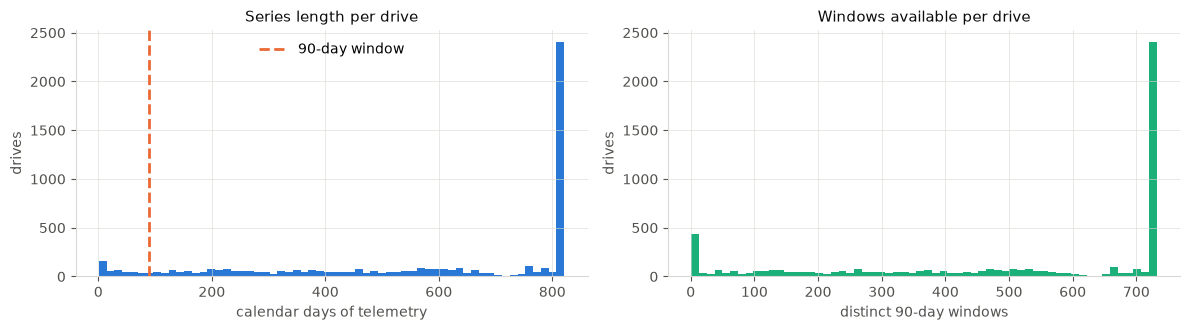

         days   count  windows
count  5589.0  5589.0   5589.0
mean    579.8   576.9    495.0
std     275.2   274.6    267.0
min       1.0     1.0      1.0
25%     355.0   354.0    266.0
50%     685.0   678.0    596.0
75%     821.0   820.0    732.0
max     821.0   821.0    732.0
  drives with >=  30 days: 5,364 (96.0%)
  drives with >=  90 days: 5,176 (92.6%)
  drives with >= 180 days: 4,882 (87.4%)
  drives with >= 365 days: 4,142 (74.1%)


In [3]:
# How much telemetry does each drive actually have? A 90-day window needs more than 90
# days of calendar before "draw a random window" means anything at all.
span = raw_df.groupby("id", observed=True)["time"].agg(["min", "max", "count"])
span["days"] = (span["max"] - span["min"]).dt.days + 1
span["windows"] = (span["days"] - 90 + 1).clip(lower=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].hist(span["days"], bins=60, color=BLUE)
axes[0].axvline(90, color=ORANGE, ls="--", label="90-day window")
axes[0].set_xlabel("calendar days of telemetry"); axes[0].set_ylabel("drives")
axes[0].set_title("Series length per drive"); axes[0].legend()
axes[1].hist(span["windows"], bins=60, color=AQUA)
axes[1].set_xlabel("distinct 90-day windows"); axes[1].set_ylabel("drives")
axes[1].set_title("Windows available per drive")
plt.tight_layout(); plt.show()

print(span[["days", "count", "windows"]].describe().round(1).to_string())
for t in (30, 90, 180, 365):
    print(f"  drives with >= {t:>3} days: {int((span['days'] >= t).sum()):,} "
          f"({100 * (span['days'] >= t).mean():.1f}%)")

## 3. Windowing

`DriveSeriesStore` puts every drive on a **gap-free daily calendar**: a drive seen on the
1st and the 5th gets rows for the 2nd–4th, forward-filled from the last real reading and
flagged in an `observed` channel the model can see. Counters are `log1p`-compressed, and
7-day differences are added as extra channels — 19 channels in all. (A 1-day
difference channel is available via `delta_lags=(1, 7)`; it is left out here because a
kernel-3 convolution computes it in its first layer anyway, and 20M rows x 9 extra
float32 channels is 750 MB of RAM that this machine would rather spend elsewhere.)

The label rule is the one thing that must be exactly right:

> **y = 1** if a `failure == 1` event falls inside `[start, start + 89]`, else **0**.

`failure` itself is held in a separate array and is never part of X.

In [4]:
cfg = DataConfig(
    window_days=90,
    horizon_days=0,          # strict: the failure must land INSIDE the window
    stride_days=30,          # val/test enumerate a window every N days
    samples_per_drive=2,     # random training windows per drive per epoch
    train_positive_ratio=0.5,
    min_days=30,             # shorter drives are dropped; 30-89 days are left-padded
    delta_lags=(7,),         # channels: levels + 7-day deltas + the observed mask
    feature_columns=tuple(FEATURE_COLUMNS),
    log1p_columns=tuple(LOG1P_COLS),
    random_state=SEED,
)

bundle = build_window_bundle(raw_df, cfg)

# The store holds its own dense copy; the 20M-row frame is not needed again.
del raw_df
gc.collect()
print(f"\nX channels ({bundle.num_features}): {bundle.feature_names}")

DriveSeriesStore: 5,364 drives, 3,237,507 dense drive-days (3,221,496 observed, 16,011 forward-filled gaps), 33 features, 2,627 drives with a failure event



Window datasets (window_days=90, horizon_days=0, stride_days=30):
  train | random    |    7,290 windows |  3,645 drives (1,785 with a positive window) | positive rate 26.255% (expected)
  val   | enumerate |   12,131 windows |    645 drives (316 with a positive window) | positive rate  2.687% (exact)
  test  | enumerate |   20,193 windows |  1,074 drives (526 with a positive window) | positive rate  2.644% (exact)

Grouped split integrity: no drive id is shared between splits (asserted in grouped_drive_split).
Raw pos_weight from the training positive rate: 2.8
Bundle built in 8.5s

X channels (33): ['smart_3_raw', 'smart_4_raw', 'smart_5_raw', 'smart_9_raw', 'smart_12_raw', 'smart_192_raw', 'smart_193_raw', 'smart_194_raw', 'smart_196_raw', 'smart_198_raw', 'smart_199_raw', 'smart_191_raw', 'smart_197_raw', 'smart_220_raw', 'smart_222_raw', 'smart_226_raw', 'smart_3_raw_d7', 'smart_4_raw_d7', 'smart_5_raw_d7', 'smart_9_raw_d7', 'smart_12_raw_d7', 'smart_192_raw_d7', 'smart_193_raw_d

## 4. Sanity checks — before a single gradient step

`run_sanity_checks` prints, in order:

1. **the leakage guard** — that `failure` is absent from X and that no channel is a copy
   of it;
2. **split integrity** — drive counts per split and the (empty) pairwise id overlaps;
3. **window counts** and the positive rate per split;
4. **representative windows** — drive id, start/end dates, tensor shape, label, how much
   of the window is real vs. forward-filled vs. padded, and the actual values across the
   90 days in both scaled and original units;
5. **the first train and test batches** as they come out of the DataLoader — shape, label
   distribution, value statistics, and a numeric slice.

In [5]:
tcfg = TrainConfig(
    arch=ARCH, hidden_dim=HIDDEN_DIM, dropout=0.2,
    batch_size=BATCH_SIZE, lr=1e-3, max_epochs=MAX_EPOCHS, patience=PATIENCE,
    loss="bce_pos_weight", sampler=SAMPLER, balanced_pos_fraction=0.25,
    num_workers=0, seed=SEED,
)
loaders = build_loaders(bundle, tcfg, device)
run_sanity_checks(bundle, loaders, n_samples=3)

LEAKAGE GUARD
  'failure' present in X feature names ......... False
  label-like column names in X ................. none
  any X column identical to the failure flag ... False
  the failure flag lives in store.failure, shape (3237507,), used only by window_label()

  X carries 33 channels:
    levels (16): ['smart_3_raw', 'smart_4_raw', 'smart_5_raw', 'smart_9_raw', 'smart_12_raw', 'smart_192_raw', 'smart_193_raw', 'smart_194_raw', 'smart_196_raw', 'smart_198_raw', 'smart_199_raw', 'smart_191_raw', 'smart_197_raw', 'smart_220_raw', 'smart_222_raw', 'smart_226_raw']
    deltas d7 (16): ['smart_3_raw_d7', 'smart_4_raw_d7', 'smart_5_raw_d7', 'smart_9_raw_d7', 'smart_12_raw_d7', 'smart_192_raw_d7', 'smart_193_raw_d7', 'smart_194_raw_d7', 'smart_196_raw_d7', 'smart_198_raw_d7', 'smart_199_raw_d7', 'smart_191_raw_d7', 'smart_197_raw_d7', 'smart_220_raw_d7', 'smart_222_raw_d7', 'smart_226_raw_d7']
    mask (1): ['observed']  -- 1 = real reading, 0 = filled gap / pad
SPLIT INTEGRITY (grouped

BATCH INSPECTION -- first batch of the 'train' DataLoader
  X batch .............. (512, 90, 33)  dtype=torch.float32  (batch, window_days, num_features)
  y batch .............. (512, 1)  dtype=torch.float32
  label distribution ... 0 -> 391 (76.37%)   1 -> 121 (23.63%)
  X stats .............. min -52.582  max 125.781  mean 0.078  std 1.149
  non-finite values .... 0
    sample: drive Z2C0A003FVKG  2024-02-04 -> 2024-05-03  y=0  real/filled/pad=90/0/0
    sample: drive Z820A01DF97G  2024-09-21 -> 2024-12-19  y=0  real/filled/pad=88/2/0
  X[0, :4, :6] =
    t00    -0.810    -0.701    -0.212    -3.667    -0.678    -0.098
    t01    -0.810    -0.701    -0.212    -3.636    -0.678    -0.098
    t02    -0.810    -0.701    -0.212    -3.620    -0.678    -0.098
    t03    -0.810    -0.701    -0.212    -3.591    -0.678    -0.098
----------------------------------------------------------------------------------------
BATCH INSPECTION -- first batch of the 'test' DataLoader
  X batch ...........

## 5. Model

A dilated 1D CNN over the window. Dilations 1→16 across five residual blocks give a
receptive field of 125 days, so the classification head sees the whole window at once.
Pooling concatenates mean, max and the final timestep: the level, the worst moment, and
the drive's most recent state.

`GRUWindowClassifier` and `TransformerWindowClassifier` are drop-in alternatives with the
same `(B, 90, F) -> (B, 1)` contract.

In [6]:
model = build_model(bundle.num_features, cfg.window_days, tcfg).to(device)
print(f"{tcfg.arch}: {count_parameters(model):,} trainable parameters\n")
print(model)

with torch.no_grad():
    probe = torch.zeros(4, cfg.window_days, bundle.num_features, device=device)
    print(f"\nforward: {tuple(probe.shape)} -> {tuple(model(probe).shape)}  (one logit per window)")

cnn: 77,041 trainable parameters

CNN1DWindowClassifier(
  (blocks): Sequential(
    (0): TemporalBlock(
      (conv1): Conv1d(33, 48, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv1d(48, 48, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (drop): Dropout(p=0.2, inplace=False)
      (act): GELU(approximate='none')
      (down): Conv1d(33, 48, kernel_size=(1,), stride=(1,))
    )
    (1): TemporalBlock(
      (conv1): Conv1d(48, 48, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (bn1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv1d(48, 48, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (bn2): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, tra

## 6. Training

Early stopping on **validation PR-AUC**, not loss or accuracy: at a positive rate of a
fraction of a percent, accuracy is meaningless and the loss moves with the imbalance
correction rather than with the ranking that actually gets used.

The imbalance is corrected **once** — a balanced sampler oversamples failure-carrying
drives, and `make_criterion` therefore drops `pos_weight` back to 1. Correcting it twice
is the mistake documented in `TOSHIBA_PIPELINE.md`.

In [7]:
t0 = time.time()
model, history, best_val_pr_auc = train_model(model, loaders, bundle, tcfg, device)
print(f"\nbest validation PR-AUC {best_val_pr_auc:.4f} in {(time.time() - t0) / 60:.1f} min")

Loss: BCEWithLogitsLoss(pos_weight=2.8; raw class ratio 2.8)


BATCH INSPECTION -- training step 0 (epoch 1)
  X batch .............. (512, 90, 33)  dtype=torch.float32  (batch, window_days, num_features)
  y batch .............. (512, 1)  dtype=torch.float32
  label distribution ... 0 -> 390 (76.17%)   1 -> 122 (23.83%)
  X stats .............. min -49.307  max 136.413  mean 0.096  std 1.360
  non-finite values .... 0
    sample: drive 61A0A11LF97G  2025-05-16 -> 2025-08-13  y=0  real/filled/pad=90/0/0
    sample: drive 23K0A0H9FVKG  2024-09-24 -> 2024-12-22  y=0  real/filled/pad=90/0/0
  X[0, :4, :6] =
    t00     0.354    -1.179    -0.212     0.634    -1.149    -0.699
    t01     0.354    -1.179    -0.212     0.635    -1.149    -0.699
    t02     0.354    -1.179    -0.212     0.636    -1.149    -0.699
    t03     0.354    -1.179    -0.212     0.637    -1.149    -0.699
----------------------------------------------------------------------------------------


BATCH INSPECTION -- validation -- first batch (inference)
  X batch .............. (512, 90, 33)  dtype=torch.float32  (batch, window_days, num_features)
  y batch .............. (512, 1)  dtype=torch.float32
  label distribution ... 0 -> 503 (98.24%)   1 -> 9 (1.76%)
  X stats .............. min -46.080  max 45.967  mean 0.040  std 0.766
  non-finite values .... 0
    sample: drive 1050A076F97G  2024-01-01 -> 2024-03-30  y=0  real/filled/pad=90/0/0
    sample: drive 1050A076F97G  2024-01-31 -> 2024-04-29  y=0  real/filled/pad=90/0/0
  X[0, :4, :6] =
    t00     0.235    -0.923    -0.212     0.376    -0.897    -0.459
    t01     0.235    -0.923    -0.212     0.377    -0.897    -0.459
    t02     0.235    -0.923    -0.212     0.378    -0.897    -0.459
    t03     0.235    -0.923    -0.212     0.379    -0.897    -0.459
----------------------------------------------------------------------------------------


epoch   1 | train_loss 0.9098 (pos seen 1,908/7,290) | val_loss 0.6607 | val PR-AUC 0.2292 | val ROC-AUC 0.7807 | val F1@0.5 0.2952 | 24.6s


epoch   2 | train_loss 0.7896 (pos seen 1,867/7,290) | val_loss 0.5128 | val PR-AUC 0.2660 | val ROC-AUC 0.8284 | val F1@0.5 0.2968 | 23.9s


...

epoch   4 | train_loss 0.6889 (pos seen 1,904/7,290) | val_loss 0.3903 | val PR-AUC 0.3104 | val ROC-AUC 0.8601 | val F1@0.5 0.3059 | 24.6s


epoch   5 | train_loss 0.6395 (pos seen 1,913/7,290) | val_loss 0.3693 | val PR-AUC 0.3115 | val ROC-AUC 0.8626 | val F1@0.5 0.3232 | 23.9s


epoch   6 | train_loss 0.6502 (pos seen 1,958/7,290) | val_loss 0.3819 | val PR-AUC 0.3170 | val ROC-AUC 0.8661 | val F1@0.5 0.2786 | 26.5s


epoch   7 | train_loss 0.6246 (pos seen 1,905/7,290) | val_loss 0.3823 | val PR-AUC 0.3147 | val ROC-AUC 0.8697 | val F1@0.5 0.2870 | 24.5s


epoch   8 | train_loss 0.6312 (pos seen 1,945/7,290) | val_loss 0.3788 | val PR-AUC 0.3102 | val ROC-AUC 0.8704 | val F1@0.5 0.2941 | 24.3s

best validation PR-AUC 0.3170 in 3.3 min


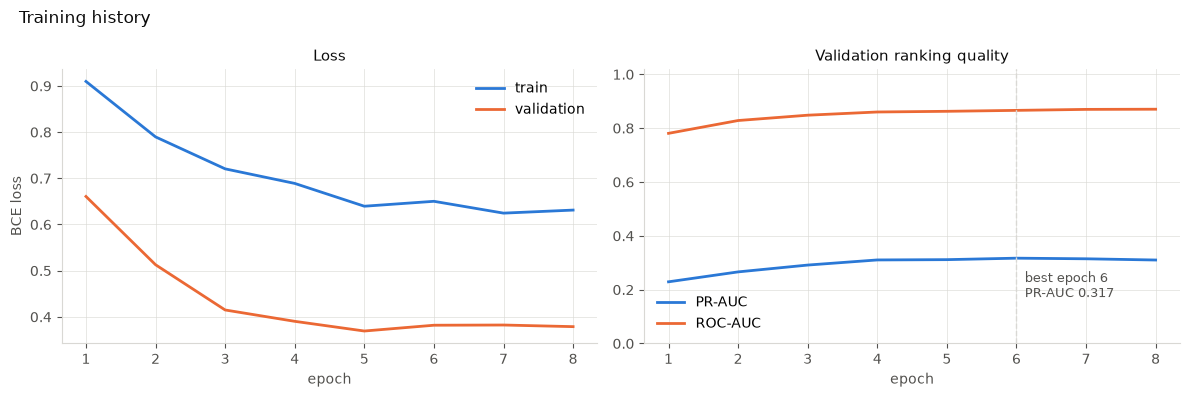

In [8]:
epochs = np.arange(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], color=BLUE, label="train")
axes[0].plot(epochs, history["val_loss"], color=ORANGE, label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE loss"); axes[0].legend()

axes[1].plot(epochs, history["val_pr_auc"], color=BLUE, label="PR-AUC")
axes[1].plot(epochs, history["val_roc_auc"], color=ORANGE, label="ROC-AUC")
axes[1].set_title("Validation ranking quality")
axes[1].set_xlabel("epoch"); axes[1].set_ylim(0, 1.02); axes[1].legend()

best = int(np.nanargmax(history["val_pr_auc"])) + 1
axes[1].axvline(best, color=GRID, linestyle="--", linewidth=1)
axes[1].annotate(f"best epoch {best}\nPR-AUC {max(history['val_pr_auc']):.3f}",
                 xy=(best, max(history["val_pr_auc"])), xytext=(6, -28),
                 textcoords="offset points", color=INK_2, fontsize=9)
fig.suptitle("Training history", x=0.02, ha="left", color=INK, fontsize=12)
plt.tight_layout(); plt.show()

## 7. Evaluation

The decision threshold is tuned on **validation only**, then frozen and applied once to
the test split. Test windows are enumerated deterministically every 15 days, so this
number is reproducible.

In [9]:
results = evaluate_final(model, loaders, bundle, tcfg, device)
test_probs, test_targets = results["test_probs"], results["test_targets"]

THRESHOLD TUNING (validation only)
  best F1 threshold .... 0.8230  (val F1 0.4249)
BATCH INSPECTION -- test -- first batch (inference)
  X batch .............. (512, 90, 33)  dtype=torch.float32  (batch, window_days, num_features)
  y batch .............. (512, 1)  dtype=torch.float32
  label distribution ... 0 -> 506 (98.83%)   1 -> 6 (1.17%)
  X stats .............. min -45.480  max 92.443  mean 0.046  std 0.939
  non-finite values .... 0
    sample: drive 1070A0DJF97G  2024-01-01 -> 2024-03-30  y=0  real/filled/pad=90/0/0
    sample: drive 1070A0DJF97G  2024-01-31 -> 2024-04-29  y=0  real/filled/pad=90/0/0
  X[0, :4, :6] =
    t00     0.329    -0.173    -0.212     0.452    -0.156    -0.098
    t01     0.329    -0.173    -0.212     0.454    -0.156    -0.098
    t02     0.329    -0.173    -0.212     0.454    -0.156    -0.098
    t03     0.329    -0.173    -0.212     0.456    -0.156    -0.098
----------------------------------------------------------------------------------------


TEST @ threshold 0.5
  windows evaluated .... 20,193  (534 positive, base rate 2.644%)
  PR-AUC ............... 0.3433   (a random ranker scores 0.0264)
  ROC-AUC .............. 0.8733
  threshold ............ 0.5000
  precision ............ 0.1864
  recall ............... 0.7097
  F1 ................... 0.2953
  confusion ............ TP 379  FP 1654  FN 155  TN 18005
TEST @ tuned threshold 0.8230
  windows evaluated .... 20,193  (534 positive, base rate 2.644%)
  PR-AUC ............... 0.3433   (a random ranker scores 0.0264)
  ROC-AUC .............. 0.8733
  threshold ............ 0.8230
  precision ............ 0.3880
  recall ............... 0.4120
  F1 ................... 0.3996
  confusion ............ TP 220  FP 347  FN 314  TN 19312
SUMMARY
  val   @tuned           PR-AUC 0.3170 | ROC-AUC 0.8661 | P 0.4016 | R 0.4509 | F1 0.4249 | thr 0.8230 | TP 147 FP 219 FN 179 TN 11586
  test  @0.50            PR-AUC 0.3433 | ROC-AUC 0.8733 | P 0.1864 | R 0.7097 | F1 0.2953 | thr 0.5000 | 

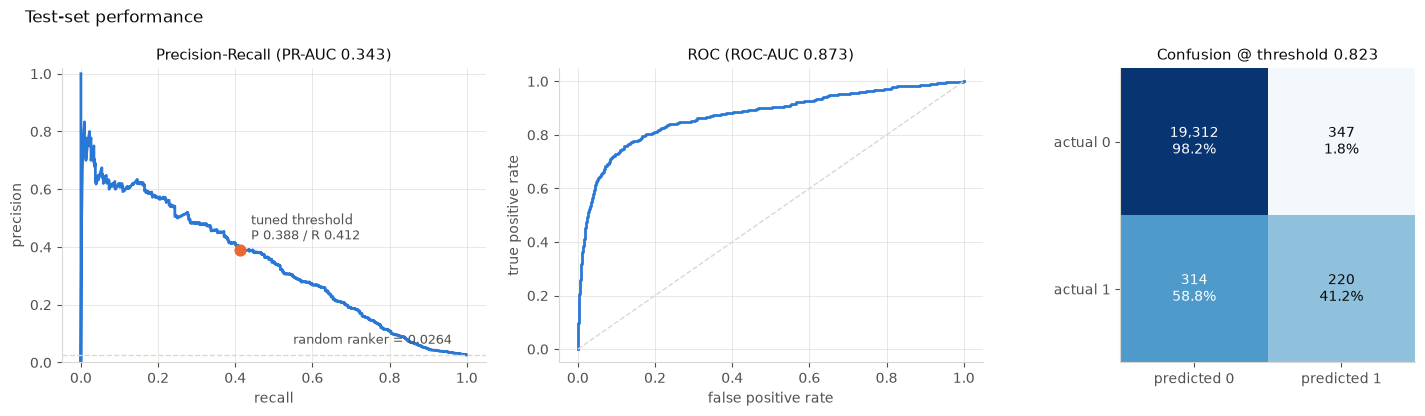

In [10]:
prec, rec, _ = precision_recall_curve(test_targets, test_probs)
fpr, tpr, _ = roc_curve(test_targets, test_probs)
m = results["test_at_tuned"]
base = test_targets.mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].plot(rec, prec, color=BLUE)
axes[0].axhline(base, color=GRID, linestyle="--", linewidth=1)
axes[0].annotate(f"random ranker = {base:.4f}", xy=(0.55, base), xytext=(0, 8),
                 textcoords="offset points", color=INK_2, fontsize=9)
axes[0].scatter([m["recall"]], [m["precision"]], s=60, color=ORANGE, zorder=3)
axes[0].annotate(f"tuned threshold\nP {m['precision']:.3f} / R {m['recall']:.3f}",
                 xy=(m["recall"], m["precision"]), xytext=(8, 8),
                 textcoords="offset points", color=INK_2, fontsize=9)
axes[0].set_title(f"Precision-Recall (PR-AUC {m['pr_auc']:.3f})")
axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision"); axes[0].set_ylim(0, 1.02)

axes[1].plot(fpr, tpr, color=BLUE)
axes[1].plot([0, 1], [0, 1], color=GRID, linestyle="--", linewidth=1)
axes[1].set_title(f"ROC (ROC-AUC {m['roc_auc']:.3f})")
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")

cm = np.array([[m["tn"], m["fp"]], [m["fn"], m["tp"]]])
axes[2].imshow(cm / cm.sum(axis=1, keepdims=True), cmap="Blues", vmin=0, vmax=1)
axes[2].set_xticks([0, 1], ["predicted 0", "predicted 1"])
axes[2].set_yticks([0, 1], ["actual 0", "actual 1"])
axes[2].grid(False)
for i in range(2):
    for j in range(2):
        share = cm[i, j] / max(cm[i].sum(), 1)
        axes[2].text(j, i, f"{cm[i, j]:,}\n{100 * share:.1f}%", ha="center", va="center",
                     color="white" if share > 0.5 else INK, fontsize=10)
axes[2].set_title(f"Confusion @ threshold {m['threshold']:.3f}")

fig.suptitle("Test-set performance", x=0.02, ha="left", color=INK, fontsize=12)
plt.tight_layout(); plt.show()

## 8. Precision@K — the number an operator actually acts on

Nobody inspects every window. They work a queue: rank the fleet by risk, look at the top
K. Precision@K is the share of that queue that really does contain a failure, and lift is
how many times better that is than picking windows at random.

,K,hits,precision@K,recall@K,lift
0,10,7,0.700,0.013,26.5x
1,25,18,0.720,0.034,27.2x
2,50,31,0.620,0.058,23.4x
3,100,60,0.600,0.112,22.7x
4,250,130,0.520,0.243,19.7x
5,500,207,0.414,0.388,15.7x
6,534,216,0.404,0.404,15.3x


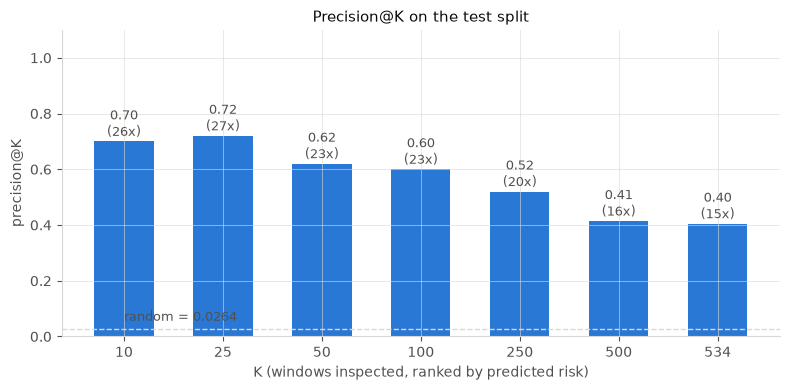

In [11]:
order = np.argsort(-test_probs)
sorted_labels = test_targets[order]
n_pos = int(test_targets.sum())
base = test_targets.mean()

rows = []
for k in [10, 25, 50, 100, 250, 500, max(n_pos, 1)]:
    k = min(k, len(sorted_labels))
    hits = int(sorted_labels[:k].sum())
    rows.append({"K": k, "hits": hits, "precision@K": hits / k,
                 "recall@K": hits / max(n_pos, 1), "lift": (hits / k) / base})
topk = pd.DataFrame(rows).drop_duplicates("K").sort_values("K").reset_index(drop=True)
display(topk.style.format({"precision@K": "{:.3f}", "recall@K": "{:.3f}", "lift": "{:.1f}x"}))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(topk["K"].astype(str), topk["precision@K"], color=BLUE, width=0.6)
ax.axhline(base, color=GRID, linestyle="--", linewidth=1)
ax.annotate(f"random = {base:.4f}", xy=(0, base), xytext=(0, 6),
            textcoords="offset points", color=INK_2, fontsize=9)
for bar, p, lift in zip(bars, topk["precision@K"], topk["lift"]):
    ax.annotate(f"{p:.2f}\n({lift:.0f}x)",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha="center", color=INK_2, fontsize=9)
ax.set_title("Precision@K on the test split")
ax.set_xlabel("K (windows inspected, ranked by predicted risk)")
ax.set_ylabel("precision@K"); ax.set_ylim(0, 1.1)
plt.tight_layout(); plt.show()

## 9. Save the model and its preprocessing

In [12]:
save_artifacts(model, bundle, tcfg, results, prefix=ARTIFACT_PREFIX)
print(json.dumps({k: v for k, v in results["test_at_tuned"].items()}, indent=2))


Saved models\toshiba_window_cnn.pth and models\toshiba_window_preprocessing_config.json
{
  "threshold": 0.8229504194690954,
  "pr_auc": 0.3432522880787221,
  "roc_auc": 0.8732525324574253,
  "precision": 0.3880070546737213,
  "recall": 0.41198501872659177,
  "f1": 0.3996366939146231,
  "tp": 220,
  "fp": 347,
  "fn": 314,
  "tn": 19312,
  "n": 20193,
  "n_pos": 534,
  "base_rate": 0.026444807606596347
}


## 10. What this does and does not tell you

**Reads on the numbers.** PR-AUC is the headline: with a positive rate well under 1%,
ROC-AUC flatters every model (the huge true-negative pool dominates it) and accuracy is
meaningless. Compare PR-AUC against the base rate printed beside it, not against 1.0.

**The strict label is hard by construction.** The daily-stats convention marks
`failure == 1` on a drive's *last* reported day, so under `horizon_days = 0` exactly one window per failing drive is
positive — the one ending on its final day. Every earlier window of that same drive, even
one from the week before it died, is a negative. A model that fires a week early is
*penalised*. Setting `horizon_days = 14` re-frames the task as "does this drive fail
within 14 days of the window's end", which is both easier and closer to what an operator
wants; it is a one-line change in cell 3.

**Cohort, not fleet.** This export is every failed drive plus a matched sample of healthy ones, so about half
the drives carry a failure and the window positive rate sits orders of magnitude above
production.
Ranking metrics (PR-AUC, Precision@K) transfer; the absolute positive rate does not.

**Next steps.** Compare the three architectures on identical splits; sweep
`horizon_days`; check whether the `observed` mask channel earns its place by ablating it;
and try `stride_days = 1` on the test split to score every possible window rather than
every 15th.